### Build a Basic chatbot woth Langgrapg(Graph API)


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph import add_messages

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]



In [4]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm = ChatGroq(model="qwen/qwen3-32b")
llm


ChatGroq(output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022F79EC67B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022F79EC74D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
    

In [7]:
graph_builder=StateGraph(State)
#Adding Nodes
graph_builder.add_node("llmchatbot",chatbot)
#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
#Add one more edge
graph_builder.add_edge("llmchatbot",END)

##compile the graph
graph = graph_builder.compile()

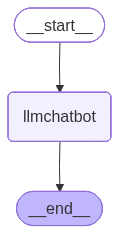

In [8]:
#visualise the graph

from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages" : "Hi there!"})
response["messages"][-1].content

'<think>\nOkay, the user said "Hi there!" so I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe add an emoji to keep it warm and approachable. I want to encourage them to ask questions or share what\'s on their mind. Let me check the tone to ensure it\'s not too formal. Alright, that should cover it.\n</think>\n\nHello! 😊 How can I assist you today? Feel free to ask me any questions or let me know if there\'s something specific you\'d like help with!'

In [10]:
for event in graph.stream({"messages" : "Hii How are ypu?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with a friendly message. I should respond in a warm and welcoming way. Let's keep the tone light and approachable.

First, I'll acknowledge their greeting and offer a cheerful response. Maybe add an emoji to keep it friendly. Then, I'll ask how I can assist them today to open up the conversation and show I'm ready to help. 

I need to make sure the response is concise but not too short, and that it invites them to ask for help. Also, check for any typos in their message before responding. They wrote "How are ypu?" with a typo in "you," so I'll note that but not point it out unless it's necessary. 

Overall, the goal is to be helpful and encouraging. Let's put that together in a friendly reply.
</think>

Hi! I'm doing well, thank you! 😊 How can I assist you today?


Chatbot woth Tool

In [41]:
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results = 2)
tool.invoke("What is latest AI news?")

{'query': 'What is latest AI news?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/@AINewsOfficial',
   'title': 'AI News - YouTube',
   'content': 'AI News delivers the latest breakthroughs in artificial intelligence, machine learning, deep learning, brain computer interface, robotics, and other future',
   'score': 0.7825466,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology.',
   'score': 0.7636429,
   'raw_content': None}],
 'response_time': 1.0,
 'request_id': '5641cdea-768a-44f8-85b9-0272105d099a'}

In [38]:

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

In [39]:
tools=[tool,multiply]

In [40]:
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022F79EC67B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022F79EC74D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer 

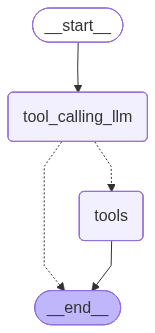

In [43]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch
from langgraph.prebuilt import tools_condition
##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
    

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

##Compile the graph

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [45]:
response = graph.invoke({"messages":"What is the recent AI news ?"})
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.6133529, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "Skip to main content\\n\\nAxios\\n\\n6 mins ago - Business\\n\\n# Axios C-Suite: 3 new AI developments for the week of June 6\\n\\n Andrew Kay\\n\\nAdd Axios on Google\\n\\nAdd Axios as your preferred source to\\n\\nsee more of our stories on Google.\\n\\nAdd Axios on Google\\n\\n1. Fast action AI software: OpenAI launched Sites, a Codex feature that lets your staff create, host and deploy work-related web apps from prompts internally — instantly.\\n\\n Why it matters: Custom software usually requires vendor contracts, engineering time or a long IT queue. Non-engineers can skip all that and build, ship and USE internal tools themse

In [48]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bczfx4k4y)
 Call ID: bczfx4k4y
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.6133529, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "Skip to main content\n\nAxios\n\n6 mins ago - Business\n\n# Axios C-Suite: 3 new AI developments for the week of June 6\n\n Andrew Kay\n\nAdd Axios on Google\n\nAdd Axios as your preferred

In [53]:
response = graph.invoke({"messages" : "what is the multiplocation of 5 and 2 ?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the multiplocation of 5 and 2 ?
================================== Ai Message ==================================
Tool Calls:
  multiply (j33jh01r5)
 Call ID: j33jh01r5
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [55]:
response = graph.invoke({"messages" : "Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (31k0kgecv)
 Call ID: 31k0kgecv
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
  multiply (9kx6wtjge)
 Call ID: 9kx6wtjge
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.6133529, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "Skip to main content\n\nAxios\n\n6 mins ago - Business\n\n# Axios C-Suite: 3 new AI developmen

### React Architecture

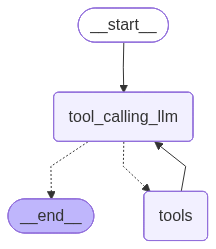

In [58]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch
from langgraph.prebuilt import tools_condition
##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
    

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##Compile the graph

graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
response = graph.invoke({"messages" : "Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (n1x6jssq1)
 Call ID: n1x6jssq1
  Args:
    query: recent AI news
    time_range: week
    topic: news
  multiply (tfxt2zzet)
 Call ID: tfxt2zzet
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.7783298, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a Codex 

### Adding memori in the Agentic Graph

In [61]:
response = graph.invoke({"messages" :"Hello My name is Venky"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello My name is Venky
================================== Ai Message ==================================

Hello Venky! How can I assist you today?


In [63]:
response = graph.invoke({"messages" : "Hello What is my Nmae"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello What is my Nmae
================================== Ai Message ==================================

You haven't provided your name in this conversation. I don't have access to personal information about users. Would you like to tell me your name so I can address you properly?


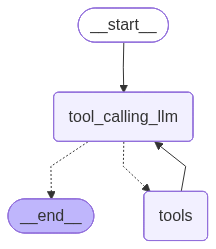

In [65]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langchain_tavily import TavilySearch
from langgraph.prebuilt import tools_condition

from langgraph.checkpoint.memory import MemorySaver

memory =MemorySaver()
##Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}
    

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add edges
builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    #If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    #If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##Compile the graph

graph=builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [66]:
config = {"configurable" : {"thread_id":"1"}}

response = graph.invoke({"messages" : "'Hey myname is Venky"},config=config)

for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

'Hey myname is Venky
================================== Ai Message ==================================

Hi Venky! How can I assist you today?


In [69]:
respone = graph.invoke({"messages" : "Do you remember my Name"},config=config)

print(response["messages"][-1].content)


Hi Venky! How can I assist you today?


### Streaming

In [70]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()



In [71]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

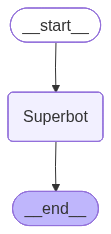

In [72]:
graph = StateGraph(State)

graph.add_node("Superbot",superbot)

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image,display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [74]:
config = {"configurable" : {"thread_id":"superbot_thread"}}

graph_builder.invoke({"messages" : "Hello My name is Venky"},config=config)

{'messages': [HumanMessage(content='Hello My name is Venky', additional_kwargs={}, response_metadata={}, id='7123eb0f-a0a1-4678-9a6b-9967cc69d4cf'),
  AIMessage(content='<think>\nOkay, the user introduced himself as Venky. I should respond politely and ask how I can assist him. Keep the tone friendly and open-ended.\n</think>\n\nHi Venky! Nice to meet you. How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 14, 'total_tokens': 67, 'completion_time': 0.100628693, 'completion_tokens_details': None, 'prompt_time': 0.000529821, 'prompt_tokens_details': None, 'queue_time': 0.101676194, 'total_time': 0.101158514}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb503-9cf7-7bd1-9f31-b85442acb2d9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_

In [ ]:
#create a thread
config = {"configurable" : {"thread_id":"3"}}

for chunk in graph_builder.stream({"messages" : "Hi my name is Venly i like cricket"},config = config,stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Venly i like cricket', additional_kwargs={}, response_metadata={}, id='62569730-4a0e-40cc-b4c0-a09282d75659'), AIMessage(content="<think>\nOkay, the user is Venly and has mentioned liking cricket. I should start by acknowledging their name and interest in cricket. For a user who is new to the conversation, it's important to create a welcoming atmosphere. I'll respond in a friendly and open manner, and ask if there's anything specific they'd like to talk about related to cricket.\n\nI need to keep it simple and open-ended. Since there's no prior conversation history, I avoid making assumptions but show genuine interest. I'll use emojis to keep the tone friendly and approachable.\n\nI should maintain a natural, conversational style without any markdown formatting. Keep the response concise but warm. Make sure to invite further discussion without being pushy. The goal is to establish a comfortable starting point for the conversation.\n</th

In [77]:
#create a thread
config = {"configurable" : {"thread_id":"4"}}

for chunk in graph_builder.stream({"messages" : "Hi my name is Venly i like cricket"},config = config,stream_mode = "updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Venly and mentioned they like cricket. I should respond with a friendly greeting and engage them in conversation about cricket. Let me check what I know about cricket and possible topics to discuss.\n\nFirst, I should acknowledge their introduction and express enthusiasm about their interest in cricket. Maybe ask about their favorite teams or players. Also, perhaps ask if they follow a particular format like Test, ODI, or T20. It's important to keep the conversation open-ended to encourage them to share more.\n\nI should avoid making assumptions but be ready to provide information or discuss various aspects of cricket. Maybe mention some current events in cricket if I know any. Also, be respectful and supportive, encouraging them to ask questions or share their experiences.\n\nWait, I need to make sure my response is welcoming and not too long. Let me structure it: Greeting, mention their nam

In [80]:
#create a thread

for chunk in graph_builder.stream({"messages" : "I also like football"},config = config,stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is Venly i like cricket', additional_kwargs={}, response_metadata={}, id='d1afc490-00f0-4422-88b7-95b5984dc7e8'), AIMessage(content="<think>\nOkay, the user introduced themselves as Venly and mentioned they like cricket. I should respond with a friendly greeting and engage them in conversation about cricket. Let me check what I know about cricket and possible topics to discuss.\n\nFirst, I should acknowledge their introduction and express enthusiasm about their interest in cricket. Maybe ask about their favorite teams or players. Also, perhaps ask if they follow a particular format like Test, ODI, or T20. It's important to keep the conversation open-ended to encourage them to share more.\n\nI should avoid making assumptions but be ready to provide information or discuss various aspects of cricket. Maybe mention some current events in cricket if I know any. Also, be respectful and supportive, encouraging them to ask questions or share their

In [ ]:
#create a thread
config = {"configurable" : {"thread_id":"5"}}

for chunk in graph_builder.astream_events({"messages" : "Hi my name is Venly i like cricket"},config = config,stream_mode = "values"):
    print(chunk)

### Humna in the loop

In [81]:
2 + 2

4

In [85]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:qwen/qwen3-32b")

llm

ChatGroq(output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022F7B25CB00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022F7B25D480>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [109]:
from typing import Annotated
from langchain_tavily import TavilySearch

from typing_extensions import TypedDict
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from langgraph.types import Command,interrupt

class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder = StateGraph(State)

@tool
def human_assistance(query:str)->str:
    """Request assistance from a human"""
    human_response = interrupt({"Query": query})
    return human_response["data"]

tool = TavilySearch(max_results = 2)

tools = [human_assistance,tool]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    message = llm_with_tools.invoke(state["messages"])
    #Because we will be interrupting during tool execution
    #We disable parellel tool calling to avoid repeating any
    #tool invocations when we resume
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools = tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)


graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")



memory = MemorySaver()

graph = graph_builder.compile(
    checkpointer=memory
)

In [110]:
print(type(graph))

<class 'langgraph.graph.state.CompiledStateGraph'>


In [107]:
grpah = graph_builder.compile(checkpointer=MemorySaver())

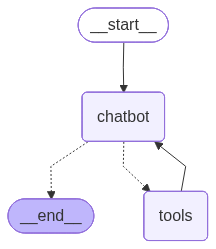

In [102]:
from IPython.display import Image,display

try:
    display(Image(grpah.get_graph().draw_mermaid_png()))
except Exception as e:
    pass


In [114]:
user_input = "I need some expert guidance and assistance for building AI agent.Could you requst assisatnce for me "

config = {"configurable" : {"thread_id":"6"}}

events = graph.stream(
    {"messages" : user_input},
    config,
    stream_mode = "values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building AI agent.Could you requst assisatnce for me 
================================== Ai Message ==================================

To help you build an AI agent, I’ll need more details to tailor the guidance. Could you clarify:  

### 1. **Type of AI Agent**  
   - Are you building a **rule-based agent** (e.g., chatbot with predefined responses), a **machine learning model** (e.g., image classifier), or an **autonomous agent** (e.g., game-playing AI like AlphaGo)?  
   - Does it require **reinforcement learning**, **natural language processing (NLP)**, or **computer vision**?  

### 2. **Technical Background**  
   - What programming languages/tools are you familiar with? (e.g., Python, TensorFlow, PyTorch, R)  
   - Do you have experience with machine learning frameworks or data preprocessing?  

### 3. **Use Case**  
   - What’s the agent’s purpose? (e

In [ ]:
human_response = (
    "We are the experts in generating langgraph agents"
)

human_command = Command(resume={"data" : hman_response})

